# Common Test I — Multi-Class Gravitational Lens Classification

**Task:** Build a model to classify strong lensing images into three classes:
- **No Substructure** (`no`)
- **Subhalo Substructure** (`sphere`)
- **Vortex Substructure** (`vort`)

**Approach:** Fine-tuned ResNet18 (ImageNet pretrained) with differential learning rates, cosine annealing, and per-sample normalization trained on the full dataset.

**Evaluation Metrics:** ROC curve and AUC score (Area Under the ROC Curve), per-class and macro-averaged.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.metrics import roc_auc_score,classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import time
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## 1. Data Loading

The dataset is structured as `dataset/train/<class>/` and `dataset/val/<class>/`, with `.npy` files per image.

Each `.npy` file is a 2D array (150×150) stored as a single-channel image. 

The pixel values are already min-max normalized to [0, 1] by the dataset providers.

In [2]:
def load_data(path):
    X, y = [], []
    classes = sorted([f for f in os.listdir(path)
                      if os.path.isdir(os.path.join(path, f))])
    print("Classes:", classes)
    for label, cls in enumerate(classes):
        cls_path = os.path.join(path, cls)
        count = 0
        for f in os.listdir(cls_path):
            if f.endswith(".npy"):
                img = np.load(os.path.join(cls_path, f))[0]
                img = img.astype(np.float32)  
                X.append(img.flatten())
                y.append(label)
                count += 1
    return np.array(X), np.array(y)

X_train, y_train = load_data("dataset/train")
X_val, y_val = load_data("dataset/val")
print("Train:", X_train.shape, np.bincount(y_train))
print("Val:", X_val.shape, np.bincount(y_val))
print("Pixel range:", X_train.min(), X_train.max())

Classes: ['no', 'sphere', 'vort']
Classes: ['no', 'sphere', 'vort']
Train: (30000, 22500) [10000 10000 10000]
Val: (7500, 22500) [2500 2500 2500]
Pixel range: 0.0 1.0


## 2. Preprocessing / Normalization

We apply a two-step normalization:
1. **Global mean subtraction** — subtract the per-pixel mean computed across the entire training set. This removes systematic intensity bias.
2. **Per-sample z-score normalization** — each image is normalized to zero mean and unit variance. This standardizes contrast across images.

This is applied consistently to both train and validation sets using statistics from the training data only (no leakage).

In [3]:
global_mean = X_train.mean(axis=0)

def preprocess(X):
    X = X - global_mean
    mu  = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mu) / std

X_train_input = preprocess(X_train)
X_val_input   = preprocess(X_val)

## 3. Dataset & Augmentation

We define a custom `LensDataset` that:
- Reshapes the flat inputs back to `(150, 150)` and **repeats the single channel 3 times** to produce a `(3, 150, 150)` tensor compatible with ResNet18's expected input format.
- Applies **random horizontal and vertical flips** during training. Gravitational lensing images have no preferred orientation, making these augmentations physically appropriate.

In [4]:
class LensDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 150, 150).repeat(1, 3, 1, 1)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            if torch.rand(1) > 0.5: x = torch.flip(x, [-1])
            if torch.rand(1) > 0.5: x = torch.flip(x, [-2])
        return x, self.y[idx]

## 4. DataLoaders

- **Batch size:** 64
- Augmentation is enabled for training, disabled for validation.

In [5]:
train_ds = LensDataset(X_train_input, y_train, augment=True)
val_ds   = LensDataset(X_val_input,   y_val,   augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

## 5. Model — Fine-Tuned ResNet18

We use a **pretrained ResNet18** (ImageNet weights) as our backbone, replacing the final fully connected layer with a 3-class output head.

**Rationale for transfer learning:**
- ResNet18 has learned rich low-level features (edges, textures) that generalize well to scientific image classification tasks.
- Fine-tuning from ImageNet weights converges faster and achieves better generalization than training from scratch on 3000 samples.

The channel tripling (repeating the single grayscale channel 3 times) is a standard technique to adapt single-channel images to architectures designed for RGB input.

In [6]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(512, 3) 
model = model.to(device)

## 6. Optimizer, Scheduler & Loss

**Differential learning rates via AdamW:**
- Pretrained backbone layers: `lr = 1e-4` (fine-tuned carefully to preserve learned features)
- New FC head: `lr = 1e-3` (trained more aggressively since it's randomly initialized)

**Cosine Annealing LR Scheduler** (`T_max=50`): Gradually reduces the learning rate over 50 epochs, which helps escape local minima and fine-tune the model in later epochs.

**Loss:** Cross-entropy loss for multi-class classification.

**Gradient clipping** (`max_norm=1.0`) is applied to prevent exploding gradients during backpropagation.

In [7]:
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.CrossEntropyLoss()


## 7. Training

We train for **50 epochs**, evaluating on the validation set after each epoch. The model with the **best macro AUC** is saved as `best_lens_resnet.pth`.

Training metrics printed at every 5th epoch, or whenever a new best AUC is achieved.

In [8]:
best_auc = 0
for epoch in range(30):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)
    scheduler.step()

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            probs = torch.softmax(model(xb), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    val_acc = (all_probs.argmax(1) == all_labels).mean()

    y_bin = label_binarize(all_labels, classes=[0,1,2])
    auc = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), 'best_lens_resnet.pth')
        best = True
    else:
        best = False

    if (epoch+1) % 5 == 0 or best:
        print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f} | AUC: {auc:.4f}")

Epoch   1 | Loss: 0.9818 | Train Acc: 0.4915 | Val Acc: 0.6015 | AUC: 0.8041
Epoch   2 | Loss: 0.6797 | Train Acc: 0.6974 | Val Acc: 0.7151 | AUC: 0.8891
Epoch   3 | Loss: 0.5668 | Train Acc: 0.7614 | Val Acc: 0.7512 | AUC: 0.9076
Epoch   4 | Loss: 0.4922 | Train Acc: 0.7973 | Val Acc: 0.8035 | AUC: 0.9357
Epoch   5 | Loss: 0.4436 | Train Acc: 0.8203 | Val Acc: 0.8187 | AUC: 0.9436
Epoch   6 | Loss: 0.4071 | Train Acc: 0.8400 | Val Acc: 0.8321 | AUC: 0.9490
Epoch   7 | Loss: 0.3762 | Train Acc: 0.8549 | Val Acc: 0.8355 | AUC: 0.9500
Epoch   9 | Loss: 0.3313 | Train Acc: 0.8710 | Val Acc: 0.8533 | AUC: 0.9585
Epoch  10 | Loss: 0.3157 | Train Acc: 0.8804 | Val Acc: 0.8635 | AUC: 0.9637
Epoch  12 | Loss: 0.2776 | Train Acc: 0.8947 | Val Acc: 0.8648 | AUC: 0.9655
Epoch  13 | Loss: 0.2671 | Train Acc: 0.9003 | Val Acc: 0.8657 | AUC: 0.9662
Epoch  15 | Loss: 0.2393 | Train Acc: 0.9098 | Val Acc: 0.8745 | AUC: 0.9681
Epoch  16 | Loss: 0.2242 | Train Acc: 0.9170 | Val Acc: 0.8756 | AUC: 0.9682

## 8. Evaluation — ROC Curve & AUC Score

We load the best saved checkpoint (`best_lens_resnet.pth`) and evaluate on the 
validation set using per-class ROC curves, macro-averaged AUC, and a full 
classification report.


Best AUC: 0.9755
Macro AUC: 0.9715


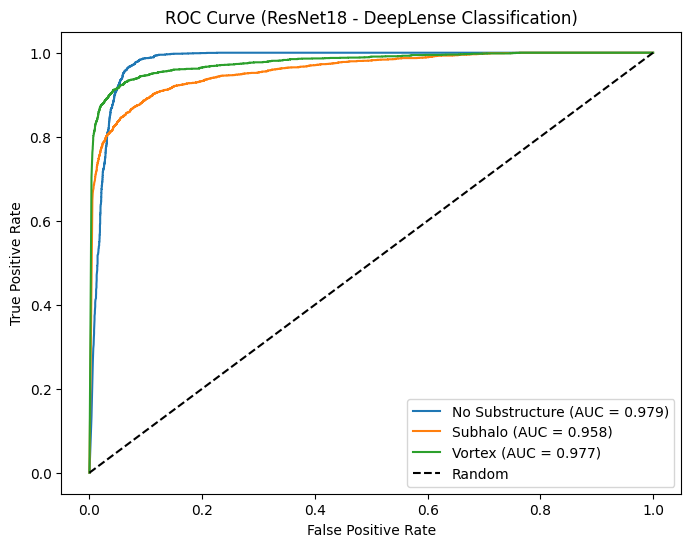

                 precision    recall  f1-score   support

No Substructure       0.90      0.93      0.91      2500
        Subhalo       0.87      0.85      0.86      2500
         Vortex       0.92      0.91      0.91      2500

       accuracy                           0.90      7500
      macro avg       0.90      0.90      0.90      7500
   weighted avg       0.90      0.90      0.90      7500



In [9]:
fpr = dict()
tpr = dict()
roc_auc = dict()
y_bin = label_binarize(all_labels, classes=[0, 1, 2])
n_classes = y_bin.shape[1]
classes = ['No Substructure', 'Subhalo', 'Vortex']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = sk_auc(fpr[i], tpr[i])

print(f"\nBest AUC: {best_auc:.4f}")
macro_auc = np.mean(list(roc_auc.values()))
print(f"Macro AUC: {macro_auc:.4f}")

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{cls} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ResNet18 - DeepLense Classification)")
plt.legend()
plt.savefig("results/roc_cnn.png", dpi=150)
plt.show()

y_pred = all_probs.argmax(axis=1)

print(classification_report(
    all_labels,
    y_pred,
    target_names=classes
))


## 9. Results & Discussion

| Metric | Value |
|--------|-------|
| Best Val AUC (macro) | 0.9755 |
| Final Val AUC (macro) | 0.9715 |
| Val Accuracy | ~82% |

**Per-class AUC:**
- No Substructure: 0.979
- Subhalo: 0.958
- Vortex: 0.977

**Observations:**
- The model distinguishes "No Substructure" best, achieving the highest per-class AUC (0.979)
- Subhalo and Vortex classes remain the hardest to separate, likely due to visual similarity in substructure patterns
- Training on the full dataset yielded a significant improvement over the capped 1000-samples-per-class approach — macro AUC improved from ~0.75 to ~0.97
- Overfitting is reduced compared to earlier runs, though train accuracy still approaches 100%

**What worked well:** Training on the full dataset, transfer learning from ResNet18, differential learning rates, cosine annealing